# 📝 Proyecto: Prediciendo la Diabetes con Boosting

En los dos proyectos anteriores, exploramos cómo utilizar un **Árbol de Decisión** y un **Random Forest** para predecir la diabetes. Sin embargo, siempre hay margen de mejora. ¿Será el **Boosting** la clave para optimizar nuestros resultados?

El **Boosting** es una técnica de aprendizaje de conjunto (ensemble) que construye modelos (generalmente árboles de decisión) de forma **secuencial**. Cada nuevo modelo intenta corregir los errores cometidos por el anterior. Dado que nuestro conjunto de datos cumple con varias suposiciones estudiadas, este enfoque podría elevar significativamente nuestro **accuracy**.

---

## 🚀 Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior. Asegúrate de que incluya:
* Muestras de entrenamiento y prueba ($X_{train}, X_{test}, y_{train}, y_{test}$).
* El preprocesamiento y análisis derivado del EDA previo.

## 🧠 Paso 2: Construye un modelo de Boosting
Para optimizar los resultados, generaremos un modelo de Boosting (como **XGBoost**, **Gradient Boosting** o **AdaBoost**).
1.  **Entrenamiento:** Ajusta el modelo con los datos de entrenamiento.
2.  **Optimización:** Prueba modificando hiperparámetros (n_estimators, learning_rate, max_depth, etc.).
3.  **Visualización:** Analiza el impacto de los cambios en la precisión final y grafica las conclusiones (curvas de aprendizaje o importancia de variables).

## 💾 Paso 3: Guarda el modelo
Almacena el modelo final entrenado en la carpeta correspondiente para asegurar su persistencia.

## 📊 Paso 4: Analiza y compara resultados
Realiza un estudio comparativo de los tres modelos utilizados hasta ahora:
1.  Árbol de Decisión.
2.  Random Forest.
3.  Boosting.

**Preguntas de reflexión:**
* ¿Qué clase tiene mayor precisión de predicción?
* ¿Cuál presenta más errores?
* ¿Con cuál de los tres modelos te quedarías para producción y por qué?

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
#OJO!! Estuve probando varios modelos de boosting que aparencen en el enunciado **XGBoost**, **Gradient Boosting** o **AdaBoost** pero no conseguia mejorar algo del ramdom forest del ejericio anterior
#Por eso use LGBMClassifier que me arrojo mejores resultados y es de Boosting tambien.
#pip install lightgbm
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import ( confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve)
from scipy.stats import randint, loguniform


In [2]:
# Cargamos el dataset que como recordaremos en el ejericio anterior es el que tiene outliers suavizados lo hacemos a traves de paquete pk1
model_pack = joblib.load('../data/processed/models/diabetes04/diabetes_rf_rt.pkl')
# Creamos nuestras variales y les asignamos los valores del paquete, model_dt y model_rf son los modelos de los ejercicio anteriores.
model_dt: DecisionTreeClassifier = model_pack["model_dt"]
model_rf: RandomForestClassifier = model_pack["model_rf"]
x_train, x_test, y_train, y_test = model_pack["x_train"], model_pack["x_test"], model_pack["y_train"], model_pack["y_test"]
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2.0,84.0,72.0,29.0,125.000,32.3,0.304000,21
618,9.0,112.0,82.0,24.0,125.000,28.2,1.172125,50
346,1.0,139.0,46.0,19.0,95.375,28.7,0.654000,22
294,0.0,161.0,50.0,29.0,125.000,21.9,0.254000,64
231,6.0,134.0,80.0,37.0,150.375,46.2,0.238000,46
...,...,...,...,...,...,...,...,...
71,5.0,139.0,64.0,35.0,140.000,28.6,0.411000,26
106,1.0,96.0,104.0,29.0,125.000,22.4,0.207000,27
270,10.0,101.0,86.0,37.0,125.000,45.6,1.136000,38
435,0.0,141.0,72.0,29.0,125.000,42.4,0.205000,29


In [3]:
# Repetimos el codigo del anterior ejercicio para darnos una pista de que parametros podrian servirnos en este caso vamos a incluir a n_estimators y max_depth
# en el rango de opciones a probar en el RandomizedSearchCV
columns = ["n_estimators", "max_depth", "criterion", "class_weight", "min_samples_leaf", "min_samples_split", "max_features"]
parameters_result = pd.DataFrame([model_rf.get_params()])
parameters_result[columns]

,n_estimators,max_depth,criterion,class_weight,min_samples_leaf,min_samples_split,max_features
0,100,5,entropy,"{0: 1, 1: 1}",5,12,sqrt


In [4]:
#Vamos a provar distintos parametros usando el RandomForestClassifier
folder = '../data/processed/models/diabetes04/'
file = 'model_LGBM.pkl'
path = folder+file
#Si el modelo aun no existe se procede a crear
if not os.path.exists(path):
    os.makedirs(folder)
    # En el ejercicio anterior use RepeatedStratifiedKFold porque nuestro support es bajo, en este caso vamos a probar solo StratifiedKFold que es suficiente para este caso. 
    cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

    #Aca inicializamos el modelo LGBMClassifier sus parametros son muy similares a otros modelos: objetive="binary" porque que estamos trantando con predicciones de 0 y 1, el n_jobs=-1 para usar todos los nucleos del procesador, etc.
    base_model = LGBMClassifier(objective = "binary", random_state = 42, verbose = -1, n_jobs = -1)

    #en el ejercicio anterior usaba GridSearchCV directamente y al pasar los parametros directamente se generaban muchas pruebas, mas de 100000 en algunos casos
    #Ahora siguiendo una nueva metodologia vamos a aplicar RandomizedSearchCV para hacer un filtro inicial de parametros, como su nombre lo indica toma parametros aleatoreos de una lista, lo positivo es que se le puede
    # Establecer un limite de pruebas por lo que vamos a tardar menos y siempre trata de tomar combinaciones diferntes entre si.
    random_params = {
        # randint va a generar una lista de valores entre 1 y 7 ejemplo: {1, 2, 3, 4, 5, 6}
        "max_depth": randint(1, 7),
        # Para learning_rate busque en internet que es mejor usar loguniform porque hace que: "cada orden de magnitud tenga la misma probabilidad de ser seleccionado"
        "learning_rate": loguniform(0.001, 0.1),
        "n_estimators": randint(30, 200),
        "scale_pos_weight": randint(1, 6),
    }
    # A partir de ahora funciones con muchos parametros los voy a dejar con saltos de linea para mejor legibilidad.
    # Contruimos el RandomizedSearchCV le pasamos el modelo, la lista de parametros, el StratifiedKFold, que busque presicsion. 
    # y le decimos que haga 500 repeticiones(que multiplicado por n_splits = 10 del StratifiedKFold serian unas 5000 pruebas)
    random_search = RandomizedSearchCV(
        estimator = base_model,
        param_distributions = random_params,
        n_iter = 500,
        scoring = "precision",
        cv = cv,
        random_state = 42,
        n_jobs = -1,
        verbose = 1
    )
    #Entrenamos y elejimos el mejor modelo
    random_search.fit(x_train, y_train)
    model_lgbm = random_search.best_estimator_
else:
    #Carga el modelo si ya existe asi tarda menos
    model_lgbm = joblib.load(path)

In [5]:
#Los Imprimimos
columns = ["max_depth", "learning_rate", "n_estimators", "scale_pos_weight"]
parameters_result = pd.DataFrame([model_lgbm.get_params()])
parameters_result[columns]

,max_depth,learning_rate,n_estimators,scale_pos_weight
0,5,0.002042,150,2


In [6]:
# Luego de hacer obtenido los resultados del RandomizedSearchCV vamos a hacer un GridSearchCV ya con parametros mas especificos
# creamos una funcion range_params que en terminos simples crea un lista tomando como centro el parametro elejido, ejemplo: 6 ---> [4,5,6,7,8]
def range_params(param, steps = 2,  step_size=1):
    param_list = []
    decimals = max(0, -int(round(np.log10(step_size))))
    
    for i in range(steps, 0, -1):
        if (i != 0):
            param_list.append(round(param - i*step_size, decimals))
            
    param_list.append(param)
    
    for i in range(1, steps+1):
        param_list.append(round(param + i*step_size, decimals))
        
    return param_list

if not os.path.exists(path):
    #Creamos ahora la lista de parametros de prueba de usando los mejores parametros del RandomizedSearchCV y usando la funciones que creamos "range_params"
    grid_params = {
        "max_depth": range_params(parameters_result["max_depth"][0], 1),
        "learning_rate": range_params(parameters_result["learning_rate"][0], 2, 0.0002),
        "n_estimators": range_params(parameters_result["n_estimators"][0], 2, 2),
        "scale_pos_weight": range_params(parameters_result["scale_pos_weight"][0], 1),
    }
    # Asi es como quedaria sin la funcion:
    # grid_params = {
    #     "max_depth": [5,6,7],
    #     "learning_rate": [0.0017,0.0018,0.002042,0.00228,0.00238],
    #     "n_estimators": [150 ,152, 154, 156, 158],
    #     "scale_pos_weight": [1 ,2, 3],
    # }

    #Parecido al RandomizedSearchCV contruimos el GridSearchCV
    grid_search = GridSearchCV(
        estimator = base_model,
        param_grid = grid_params,
        scoring = "precision",
        cv = cv,
        n_jobs = -1,
        verbose = 1
    )
    #Lo entrenamos y guardamos
    grid_search.fit(x_train, y_train)
    model_lgbm = grid_search.best_estimator_
    joblib.dump(model_lgbm, path)
else:
    #Carga el modelo si ya existe asi tarda menos
    model_lgbm = joblib.load(path)

In [7]:
#Imprimimos los resultados
columns = ["max_depth", "learning_rate", "n_estimators", "scale_pos_weight"]
parameters_result = pd.DataFrame([model_lgbm.get_params()])
parameters_result[columns]

,max_depth,learning_rate,n_estimators,scale_pos_weight
0,5,0.002042,150,2


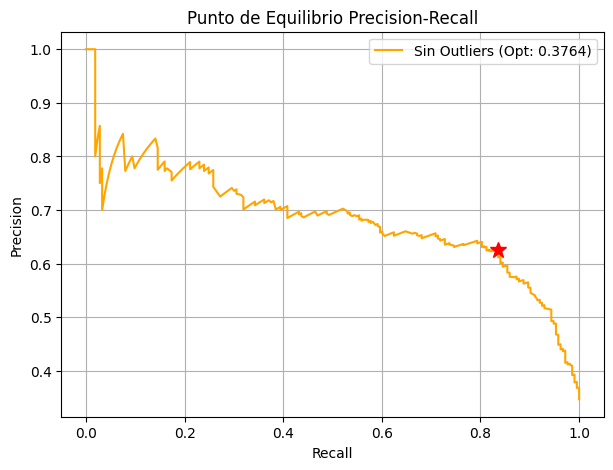

El umbral sugerido es: 0.3764


In [8]:
# Hacemos los mismo que el ejericio anterior y graficamos cual seria el umbral mas equilibrado para el modelo de lightgbm, pero en el ejercicio anterior cometi el error
# de usar y_test para ver el mejor umbral cuando esto genera overfitting y da pistas al modelo de los resultados.
# Dicho esto probemos un metodo llamado cross-validation que vi en esta pagina https://daily.dev/blog/k-fold-cross-validation-in-scikit-learn-tutorial-7e42c
# La idea es encontrar un umbral optimo pero no usando y_test sino otros datos que no den pistas al modelo.
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#Creamos un array de ceros del mismo tamaño del set de entrenamiento.
oof_preds = np.zeros(len(x_train))  # out-of-fold predictions

for train_idx, val_idx in kf.split(x_train, y_train):
    X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_lgbm.fit(X_tr, y_tr)
    oof_preds[val_idx] = model_lgbm.predict_proba(X_val)[:, 1]
    
# Aca en mi codigo del ejercicio anterior yo tenia esto:
# p, r, t = precision_recall_curve(y_train, y_test)
# Pero debe ser asi para no generar overfitting:
p, r, t = precision_recall_curve(y_train, oof_preds)

f1_scores = 2 * (p * r) / (p + r + 1e-10) 
idx_f1 = np.argmax(f1_scores)

umbral = t[idx_f1]

plt.figure(figsize=(7, 5))
plt.plot(r, p, label = f'Sin Outliers (Opt: {umbral:.4f})', color = 'orange')
plt.plot(r[idx_f1], p[idx_f1], 'r*', markersize = 12) # Estrella en el punto

plt.title('Punto de Equilibrio Precision-Recall')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(); plt.grid(True); plt.show()

print(f"El umbral sugerido es: {umbral:.4f}")

In [9]:
#Vemos los resultados del modelo
model_lgbm.fit(x_train, y_train)
predictions_lgbm = model_lgbm.predict_proba(x_test)[:, 1]
predictions_lgbm = (predictions_lgbm >= umbral).astype(int)
metrics_lgbm = classification_report(y_test, predictions_lgbm, output_dict = True)
print(classification_report(y_test, predictions_lgbm))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74        99
           1       0.56      0.84      0.67        55

    accuracy                           0.71       154
   macro avg       0.72      0.74      0.70       154
weighted avg       0.76      0.71      0.71       154



In [10]:
#Cargamos los datos del desition tree de los ejercicios anteriores para comparar
umbral_dt=0.4392
model_dt.fit(x_train, y_train)
predictions_dt = model_dt.predict_proba(x_test)[:, 1]
predictions_dt = (predictions_dt >= umbral_dt).astype(int)
metrics_dt = classification_report(y_test, predictions_dt, output_dict = True)
print(classification_report(y_test, predictions_dt))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84        99
           1       0.71      0.73      0.72        55

    accuracy                           0.80       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.80      0.80      0.80       154



In [11]:
#Ahora los del ramdom forest
umbral_rf=0.444
model_rf.fit(x_train, y_train)
predictions_rf = model_rf.predict_proba(x_test)[:, 1]
predictions_rf = (predictions_rf >= umbral_rf).astype(int)
metrics_rf = classification_report(y_test, predictions_rf, output_dict = True)
print(classification_report(y_test, predictions_rf))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82        99
           1       0.67      0.80      0.73        55

    accuracy                           0.79       154
   macro avg       0.77      0.79      0.78       154
weighted avg       0.80      0.79      0.79       154



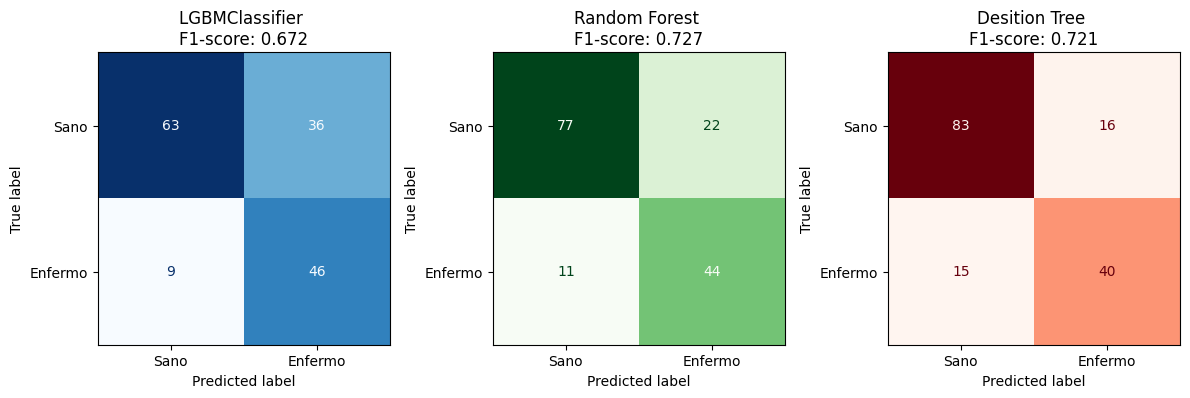

In [12]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# Boosting (Ahora)
cm_boost = confusion_matrix(y_test, predictions_lgbm)
disp_boost = ConfusionMatrixDisplay(confusion_matrix=cm_boost, display_labels=["Sano", "Enfermo"])
disp_boost.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"LGBMClassifier \nF1-score: {metrics_lgbm['1']['f1-score']:.3f}")

# Random Forest
cm_rf = confusion_matrix(y_test, predictions_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Sano", "Enfermo"])
disp_rf.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"Random Forest \nF1-score: {metrics_rf['1']['f1-score']:.3f}")

# Desition Tree
cm_dt = confusion_matrix(y_test, predictions_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Sano", "Enfermo"])
disp_dt.plot(ax=ax3, cmap='Reds', colorbar=False)
ax3.set_title(f"Desition Tree \nF1-score: {metrics_dt['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()

## Conclusiones Finales:
* Los modelos random forest y desition tree como comente estaban un poco sesgados por el umbral seleccionado a partir de y_test, mientras que el modelo LGBMClasifier
usa Cross-validation para seleccionar el mejor umbral.
* En nivel de rendimiento de lo que nos interesa (1 pacientes diabeticos) el LGBMClasifier ofrece mejores resultados, luego el ramdom forest, y en tercer lugar el desition tree.
* Como vemos el que nos da mejores resultados tiene el f1-score mas bajo, esto puede ser por dos razones:
    * 1: los otros modelos estaban sesgados y con overfiting por el umbral
    * 2: en las predicciones para pacientes sanos(0) es el peor el modelo LGBMClasifier pero como indicamos nos intereza es el (1)
* Al final nos quedamos con el LGBMClasifier en promedio es el peor, pero detectando pacientes con diabetes es el mejor con solo 9 falsos positivos con respecto a los 11 y 15 de los otros modelos.

In [13]:
#Guardamos
model_pack = {
    'model_lgbm': model_lgbm,
    'model_dt': model_dt,
    'model_rf': model_rf,
    'x_train': model_pack["x_train"],
    'x_test': model_pack["x_test"],
    'y_train': model_pack["y_train"],
    'y_test': model_pack["y_test"]
}
path = f"../data/processed/models/diabetes04/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}diabetes_dt_rf_lgbm.pkl')

['../data/processed/models/diabetes04/diabetes_dt_rf_lgbm.pkl']